Aman Shaikh
F-02

**Objective : Apply PCA for reducing dimentionality of a dataset and visualize results**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

The MNIST dataset consists of 70,000 grayscale images of handwritten digits ranging from 0 to 9.Each image has resolution of 28*28 pixles and is flattened into a 784 - dimensional feature vector, where each feature represents the intensity of a pixel.

In [2]:
mnist = fetch_openml('mnist_784', version = 1,as_frame = False)
X = mnist.data
y = mnist.target.astype(int)
print(X.shape)

(70000, 784)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(X_train_pca.shape, X_test_pca.shape)

(56000, 2) (14000, 2)


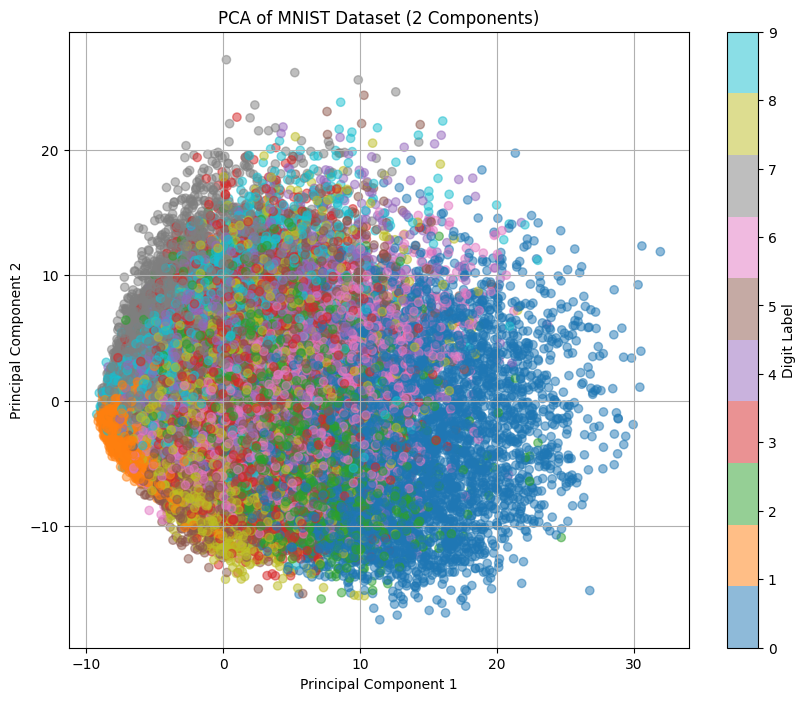

In [6]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Dataset (2 Components)')
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.grid(True)
plt.show()